In [8]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
panel_data = pd.read_csv(r'a-fanning-doughnut-v3-a0460e5\Analysis-Final\myData\11_20250115_multiPanelData.csv')

In [20]:
panel_data.head()

,domain,dimension,type,group,grpCode,indicator,indCode,date,populationTotal,GNIperCap,value,boundary,ratio
0,ecological,climate change,national aggregate,Bottom-40,B40,co2_footprint,CC3,2017,3279187003,5022.645571,0.938904,0.95,-0.011680
1,ecological,climate change,national aggregate,Middle-40,M40,co2_footprint,CC3,2017,3183138611,15659.215592,4.256704,0.95,3.480741
2,ecological,climate change,national aggregate,Top-20,T20,co2_footprint,CC3,2017,985730708,51581.715835,11.650509,0.95,11.263694
3,ecological,nutrient pollution,national aggregate,Bottom-40,B40,P_footprint,NP3,2017,3279187003,5022.645571,1.536249,0.85,0.807352
4,ecological,nutrient pollution,national aggregate,Middle-40,M40,P_footprint,NP3,2017,3183138611,15659.215592,3.081177,0.85,2.624914


In [21]:
social_short = panel_data[panel_data['domain'] == 'social']

In [25]:
social_short.reset_index(drop='True', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_20256\2253659792.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='group', y='value', palette=sns.color_palette("pastel"), ax=ax)
C:\Users\User\AppData\Local\Temp\ipykernel_20256\2253659792.py:15: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=data, x='group', y='value', palette=sns.color_palette("pastel"), ax=ax)
C:\Users\User\AppData\Local\Temp\ipykernel_20256\2253659792.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='group', y='value', palette=sns.color_palette("pastel"), ax=ax)
C:\Users\User\AppData\Local\Temp\ipykernel_20256\2253659792.py:15

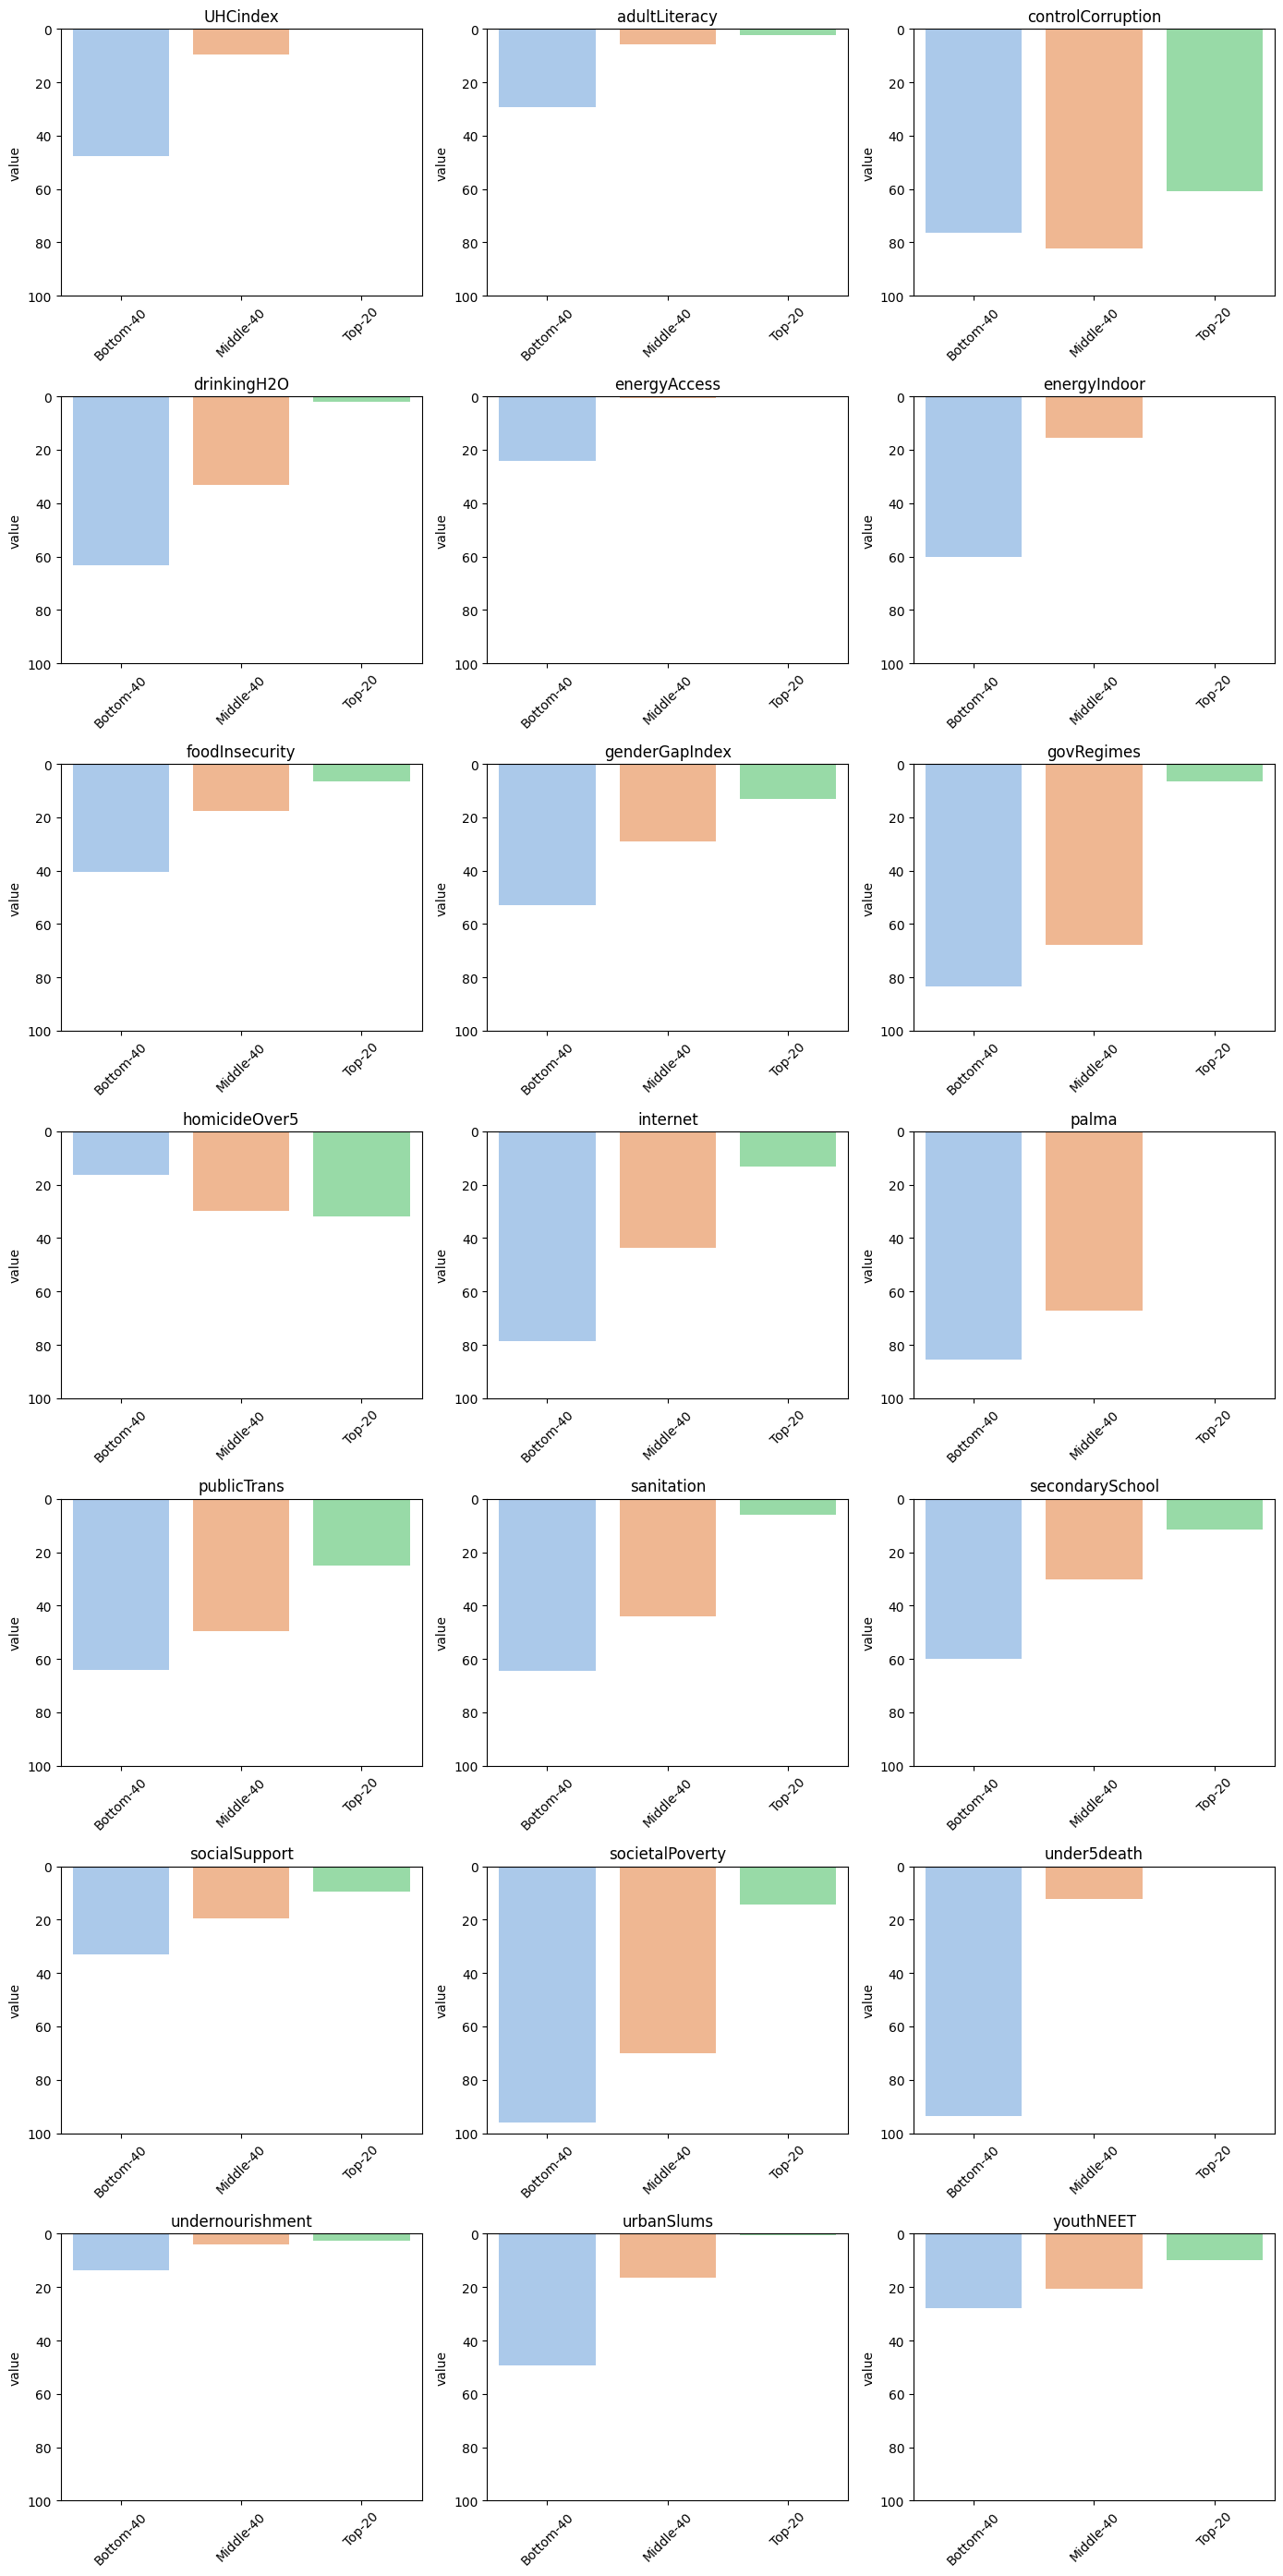

In [72]:
soc_chart = social_short.groupby(['indicator', 'group'])['value'].sum().reset_index()

indicators = soc_chart['indicator'].unique()

n_cols = 3
n_rows = -(-len(indicators) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, indicator in enumerate(indicators):
    ax = axes[i]
    data = soc_chart[soc_chart['indicator'] == indicator]
    
    sns.barplot(data=data, x='group', y='value', palette=sns.color_palette("pastel"), ax=ax)
    ax.set_title(indicator)
    ax.set_ylim(0, 100)
    ax.invert_yaxis()
    ax.set(xlabel=None)
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()